#1 Przygotowanie środowiska


In [ ]:
!pip install -q datasets
!pip install -q timm
!pip install -q torchmetrics
#!pip install -q wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 25.5 MB/s eta 0:00:00


In [ ]:
from tqdm import tqdm
from PIL import Image
from typing import List, Tuple, Dict, Optional, Any
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
import torchmetrics
import timm

Klasa `Config` zawiera definiuje parametry wykorzystywanych w notatniku modeli oraz procesu uczenia.

In [ ]:
@dataclass
class Config:
  image_size = 224              # Rozmiar obrazu w pikselach
  projection_dim = 256          # Rozmiar wektorowej reprezentacji (osadzenia)

  # Model językowy do ekstrakcji reprezentacji językowej
  text_model = "distilbert-base-uncased"
  img_model = 'resnet50'
  max_tokens = 128               # Maksymalna długość podpisu po tokenizacji

  temperature = 0.05            # Parametr temperatury w funkcji softmax

  # Parametry data loadera
  batch_size = 64
  num_workers = 1

  # Parametry treningu modelu
  num_epochs = 3

  # Wartości stopy uczenia
  image_encoder_lr = 1e-4
  text_encoder_lr = 1e-5
  projection_head_lr = 1e-3
  weight_decay = 1e-4

#2 Przygotowanie zbioru danych

##2.1 Pobranie zbióru danych


In [ ]:
from huggingface_hub import login

login()

In [ ]:
battlemaps_dataset = load_dataset("Rpgshit/battlemaps-description-generated")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/615 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

data/train-00000-of-00018.parquet:   0%|          | 0.00/467M [00:00<?, ?B/s]

...

data/test-00001-of-00003.parquet:   0%|          | 0.00/368M [00:00<?, ?B/s]

data/test-00002-of-00003.parquet:   0%|          | 0.00/313M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3965 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/496 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/496 [00:00<?, ? examples/s]

In [ ]:
print(battlemaps_dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'short_description', 'description'],
        num_rows: 3965
    })
    validation: Dataset({
        features: ['image', 'short_description', 'description'],
        num_rows: 496
    })
    test: Dataset({
        features: ['image', 'short_description', 'description'],
        num_rows: 496
    })
})


Wyświetl losowo wybrany obraz i związane z nim podpisy.

stone village with a circular road in the center many houses around the road with trees
How Many Colored Eggs Can You Find? 2023


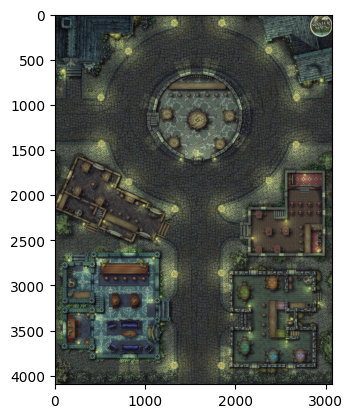

In [ ]:
import random
import matplotlib.pyplot as plt

data_item = random.choice(battlemaps_dataset['test'])
plt.imshow(data_item['image'])
print(data_item['description'])
print(data_item['short_description'])

##2.2 Przygotowanie danych tekstowych

Tokenizacja podpisów i przekształcenie ich do formatu wymaganego przez wykorzystywany model językowy (DistillBERT).

In [ ]:
from transformers import DistilBertModel, DistilBertConfig, DistilBertTokenizerFast

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(Config.text_model)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

##2.2 Przygotowanie danych wizyjnych

Przekształcenia obrazów ze zbioru danych (normalizacja, zamiana na tensor).
W trybie treningowym stosujemy urozmaicanie danych (`RandomResizedCrop`, `RandomHorizontalFlip`).


In [ ]:
# wersja obsługująca grayscale(możliwe problemy z ramem)
import torch
from torchvision.transforms import v2 as T
from torchvision.transforms.functional import to_pil_image, pil_to_tensor

def ensure_rgb(x):
    """Konwertuje dowolny obraz (1,2,3,4 kanały) do RGB."""
    if isinstance(x, torch.Tensor):
        x = to_pil_image(x)
    return pil_to_tensor(x.convert("RGB"))

def get_image_transforms(mode: str = "train"):
    base = [
        T.ToImage(),
        T.Lambda(ensure_rgb),  # <── KONWERSJA DO RGB (zawsze 3 kanały)
        T.ToDtype(torch.uint8, scale=True),
    ]

    if mode == "train":
        extra = [
            T.RandomResizedCrop(size=(Config.image_size, Config.image_size), antialias=True),
            T.RandomHorizontalFlip(p=0.5),
        ]
    else:
        extra = [
            T.Resize(size=(Config.image_size, Config.image_size), antialias=True),
        ]

    normalize = [
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
    ]

    return T.Compose(base + extra + normalize)


##2.3 CLIP dataset

In [ ]:
import random

class CLIPDataset(Dataset):
    def __init__(self, dataset: Dataset, tokenizer, image_transforms):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms
        self.raw_descriptions = []
        self.tokenized_descriptions = []

        for data_item in tqdm(dataset, desc="Tokenizacja tekstu..."):
            text = data_item["description"]
            name = data_item["short_description"]
            self.raw_descriptions.append([name, text])

            tokens = tokenizer(
                [name, text],
                add_special_tokens=True,
                padding='max_length',
                truncation=True,
                max_length=Config.max_tokens,
                return_tensors='pt'
            )
            self.tokenized_descriptions.append(tokens)

    def __getitem__(self, idx):
        image = self.dataset[idx]["image"]
        image = self.image_transforms(image)

        # Losowo albo opis albo nazwa mapy
        k = random.randrange(len(self.tokenized_descriptions[idx]))
        tokens = self.tokenized_descriptions[idx]

        input_ids = tokens["input_ids"][k]
        attention_mask = tokens["attention_mask"][k]

        return {
            "image": image,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "description": self.raw_descriptions[idx][k]
        }

    def __len__(self):
        return len(self.dataset)

In [ ]:
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

Utworzenie zbioru danych treningowych, walidacyjnych i testowych

In [ ]:
training_dataset = CLIPDataset(battlemaps_dataset['train'], tokenizer, get_image_transforms(mode="train"))
val_dataset = CLIPDataset(battlemaps_dataset['validation'], tokenizer, get_image_transforms(mode="val"))
test_dataset = CLIPDataset(battlemaps_dataset['test'], tokenizer, get_image_transforms(mode="test"))

Tokenizacja tekstu...: 100%|██████████| 496/496 [00:52<00:00,  9.38it/s]


Wyświetlenie losowo wybranych przykładów ze zbioru danych.

In [ ]:
for i in range(3):
  x = random.choice(training_dataset)
  print(f"{x['description']=}")
  print(f"{x['input_ids']=}")
  print(f"{x['attention_mask']=}")
  print(f"{x['image'].shape=}")
  print()

x['description']='room with a bed in the north east corner desk with papers and books in the north west corner rug with a diamond pattern in the center'
x['input_ids']=tensor([  101,  2282,  2007,  1037,  2793,  1999,  1996,  2167,  2264,  3420,
         4624,  2007,  4981,  1998,  2808,  1999,  1996,  2167,  2225,  3420,
        20452,  2007,  1037,  6323,  5418,  1999,  1996,  2415,   102,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,   

#3 Architektura modelu CLIP

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

class ProjectionHead(nn.Module):
    def __init__(self, embedding_dim: int, projection_dim: int):
        super().__init__()
        self.projection_dim = projection_dim
        self.projection = nn.Linear(embedding_dim, projection_dim, bias=False)

    def forward(self, x: Tensor) -> Tensor:
        y = self.projection(x)
        z = F.normalize(y, p=2, dim=-1)
        return z



##3.2 Koder danych tekstowych

In [ ]:
class TextEncoder(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.backbone = DistilBertModel.from_pretrained(Config.text_model)
    self.embedding_dim = self.backbone.config.dim
    self.CLS_token_idx = 0
    self.projection = ProjectionHead(embedding_dim=self.embedding_dim, projection_dim=Config.projection_dim)

  def forward(self, input_ids: Tensor, attention_mask: Tensor) -> Tensor:
    x = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
    last_hidden_state = x.last_hidden_state
    x = last_hidden_state[:, self.CLS_token_idx, :]
    x = self.projection(x)
    return x

##3.3 Koder danych obrazowych



In [ ]:
class ImageEncoder(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.backbone = timm.create_model(Config.img_model, pretrained=True,
                                      num_classes=0)
    self.embedding_dim = self.backbone.feature_info[-1]['num_chs']

    self.projection = ProjectionHead(
        embedding_dim=self.embedding_dim,
        projection_dim=Config.projection_dim
    )

  def forward(self, x: Tensor) -> Tensor:
    x = self.backbone(x)
    x = self.projection(x)
    return x


In [ ]:
def count_parameters(model: nn.Module) -> Tuple[int, int]:
  trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
  all_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
  return trainable_params, all_params

In [ ]:
class CLIPModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.text_encoder = TextEncoder()
    self.image_encoder = ImageEncoder()

  def forward(self, batch):
    text_embeddings = self.text_encoder(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
    image_embeddings = self.image_encoder(batch["image"])
    return text_embeddings, image_embeddings

  def print_info(self):
    print(f"Text embedding dimensionality: {self.text_encoder.embedding_dim}   projected: {self.text_encoder.projection.projection_dim}")
    print(f"Image embedding dimensionality: {self.image_encoder.embedding_dim}   projected: {self.image_encoder.projection.projection_dim}")
    nt, na = count_parameters(self.text_encoder)
    print(f"Text encoder parameters (trainable/all): {nt} / {na}")
    nt, na = count_parameters(self.image_encoder)
    print(f"Image encoder parameters (trainable/all): {nt} / {na}")
    nt, na = count_parameters(self)
    print(f"All parameters (trainable/all): {nt} / {na}")


Definicja kontrastywnej funkcji straty z temperaturą wykorzystywanej przy uczeniu modelu CLIP.

In [ ]:
def CLIP_loss(text_embeddings: Tensor, image_embeddings: Tensor) -> Tuple[Tensor, float, float]:
    assert text_embeddings.shape == image_embeddings.shape
    assert text_embeddings.device == image_embeddings.device

    n = len(text_embeddings)

    labels = torch.arange(n).to(text_embeddings.device)

    logits = (text_embeddings @ image_embeddings.T) / Config.temperature
    img_acc, cap_acc = calc_metrics(logits)

    loss_i = F.cross_entropy(logits.transpose(0, 1), labels, reduction="mean")
    loss_t = F.cross_entropy(logits, labels, reduction="mean")

    # Calculate the final loss
    loss = (loss_i + loss_t) / 2

    return loss, img_acc, cap_acc

@torch.no_grad
def calc_metrics(logits: torch.Tensor) -> Tuple[float, float]:
    y = torch.arange(len(logits)).to(logits)
    img2cap_match_idx = logits.argmax(dim=1)
    cap2img_match_idx = logits.argmax(dim=0)

    img_acc = (img2cap_match_idx == y).float().mean().item()
    cap_acc = (cap2img_match_idx == y).float().mean().item()

    return img_acc, cap_acc

#4 Trenowanie modelu

Definicja dataloaderów tworzących wsady treningowe i walidacyjne.

In [ ]:
dataloader = {
    'train': DataLoader(training_dataset, batch_size=Config.batch_size, num_workers=Config.num_workers, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=Config.batch_size, num_workers=Config.num_workers),
    'test': DataLoader(test_dataset, batch_size=Config.batch_size, num_workers=Config.num_workers)
}


Utworzenie instancji modelu klasy CLIPModel(). Utworzenie optymalizatora parametrów modelu - każda podsieć w modelu (bazowa sieć ekstrakcji cech wizyjnych, bazowa sieć ekstakcji cech z danych tekstowych, głowice projekcyjne) jest uczona z inną stopą uczenia.

In [ ]:
clip_model = CLIPModel()
clip_model.print_info()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clip_model.to(device)

params = [
  {"params": clip_model.text_encoder.backbone.parameters(), "lr": Config.text_encoder_lr},
  {"params": clip_model.image_encoder.backbone.parameters(), "lr": Config.image_encoder_lr},
  {"params": clip_model.text_encoder.projection.parameters(), "lr": Config.projection_head_lr, "weight_decay": Config.weight_decay},
  {"params": clip_model.image_encoder.projection.parameters(), "lr": Config.projection_head_lr, "weight_decay": Config.weight_decay},
]
optimizer = torch.optim.AdamW(params, weight_decay=0.)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Text embedding dimensionality: 768   projected: 256
Image embedding dimensionality: 2048   projected: 256
Text encoder parameters (trainable/all): 66559488 / 66559488
Image encoder parameters (trainable/all): 24032320 / 24032320
All parameters (trainable/all): 90591808 / 90591808


## Trenowanie

In [ ]:
from tqdm import tqdm

# Per-batch metrics
loss_metric = torchmetrics.aggregation.MeanMetric()
img_acc_metric = torchmetrics.aggregation.MeanMetric()
cap_acc_metric = torchmetrics.aggregation.MeanMetric()

for epoch in range(Config.num_epochs):
  for phase in ['train', 'val']:
    loss_metric.reset()
    img_acc_metric.reset()
    cap_acc_metric.reset()

    if phase == 'train':
      clip_model.train()
    else:
      clip_model.eval()

    for batch in tqdm(dataloader[phase]):
      batch['image'] = batch['image'].to(device)
      batch['input_ids'] = batch['input_ids'].to(device)
      batch['attention_mask'] = batch['attention_mask'].to(device)
      with torch.set_grad_enabled(phase=='train'):
        text_embeddings, image_embeddings = clip_model(batch)
        loss, img_acc, cap_acc = CLIP_loss(text_embeddings, image_embeddings)

      loss_metric.update(loss.item())
      img_acc_metric.update(img_acc)
      cap_acc_metric.update(cap_acc)

      # Backward pass and optimization
      if phase == 'train':

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if phase == 'train':
      print(f"({phase})  epoch: {epoch+1}/{Config.num_epochs}  Loss: {loss_metric.compute():.3f}")
    else:
      print(f"({phase})  epoch: {epoch+1}/{Config.num_epochs}  Loss: {loss_metric.compute():.3f}  img2text acc: {img_acc_metric.compute():.3f}  txt2img acc: {cap_acc_metric.compute():.3f}")


100%|██████████| 62/62 [21:09<00:00, 20.47s/it]


(train)  epoch: 1/3  Loss: 3.813


100%|██████████| 8/8 [02:22<00:00, 17.82s/it]


(val)  epoch: 1/3  Loss: 3.392  img2text acc: 0.124  txt2img acc: 0.122


100%|██████████| 62/62 [20:57<00:00, 20.28s/it]


...

(val)  epoch: 2/3  Loss: 2.939  img2text acc: 0.215  txt2img acc: 0.223


100%|██████████| 62/62 [20:50<00:00, 20.16s/it]


(train)  epoch: 3/3  Loss: 2.691


100%|██████████| 8/8 [02:22<00:00, 17.85s/it]

(val)  epoch: 3/3  Loss: 2.733  img2text acc: 0.243  txt2img acc: 0.258


Zwolnienie pamięci na GPU.

In [ ]:
import gc

del batch
del loss
del text_embeddings
del image_embeddings
del optimizer
gc.collect()
torch.cuda.empty_cache()
!nvidia-smi

Sun Dec 21 19:03:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             43W /   70W |    2106MiB /  15360MiB |     25%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#5 Wykorzystanie wytrenowanego modelu


In [ ]:
@torch.no_grad
def compute_image_embeddings(model: CLIPModel, dataloader) -> Tensor:
  model.eval()

  embeddings = []
  for batch in dataloader:
    img_batch = batch['image'].to(device)
    img_representation  = model.image_encoder(img_batch)
    embeddings.append(img_representation)

  return torch.cat(embeddings)

Wyznaczenie reprezentacji wszystkich obrazów ze zbioru testowego.

In [ ]:
image_embeddings = compute_image_embeddings(clip_model, dataloader['test'])
print(f"Zindeksowano {image_embeddings.shape[0]} obrazów")


Zindeksowano 496 obrazów


##5.2 Wyszukiwanie obrazów na podstawie tekstu w języku naturalnym

In [ ]:
def find_nn(query_embedding: Tensor, dataset_embeddings: Tensor, k: int) -> Tuple[List[int], List[float]]:

    assert query_embedding.ndim == 1
    assert dataset_embeddings.ndim == 2
    assert query_embedding.shape[0] == dataset_embeddings.shape[1]

    cos = nn.CosineSimilarity()
    sim = cos(query_embedding, dataset_embeddings)

    sim, nn_idx = torch.topk(sim, k=k)

    return nn_idx.tolist(), sim.tolist()

In [ ]:
def draw_search_images(query, k: int):
  tokenized_ptext = tokenizer(query, add_special_tokens=True, padding='max_length', truncation=True, max_length=Config.max_tokens, return_tensors='pt')
  clip_model.eval()
  text_prompt_embedding = clip_model.text_encoder(tokenized_ptext['input_ids'].to(device), tokenized_ptext['attention_mask'].to(device))
  text_prompt_embedding = text_prompt_embedding.squeeze(0)

  nn_idx, scores = find_nn(text_prompt_embedding, image_embeddings, k=k)
  print(f"\nWyniki dla zapytania: '{query}'")
  fig, axes = plt.subplots(1, k, figsize=(15,5))
  for i, (score, idx) in enumerate(zip(scores, nn_idx)):
    item = battlemaps_dataset['test'][idx]
    img = item['image']
    description = battlemaps_dataset['test'][idx]['short_description']
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Score: {score:.4f}\nTrue: {description[:30]}...")
  plt.show()


Wyniki dla zapytania: 'Palace Cortyard'


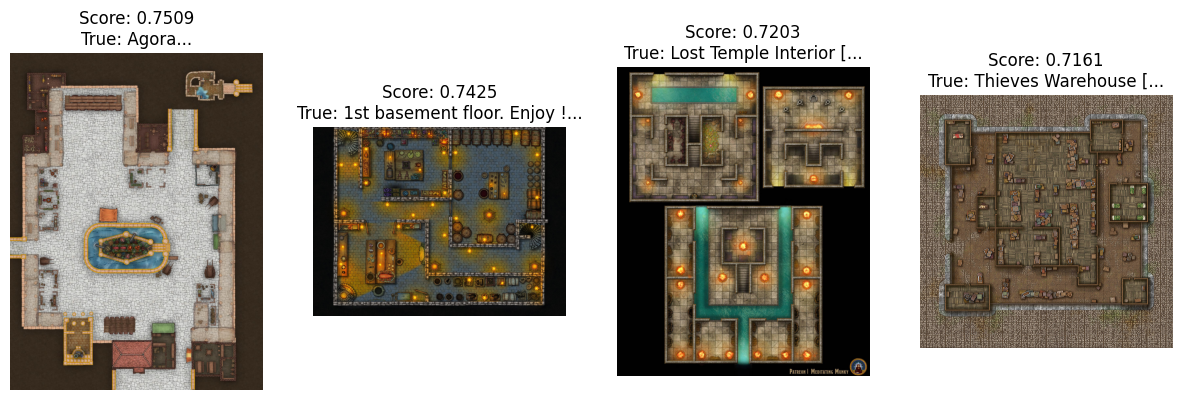

In [ ]:
text_prompt = "Palace Cortyard"
draw_search_images(text_prompt, k=4)


Wyniki dla zapytania: 'Dark cave with threasure'


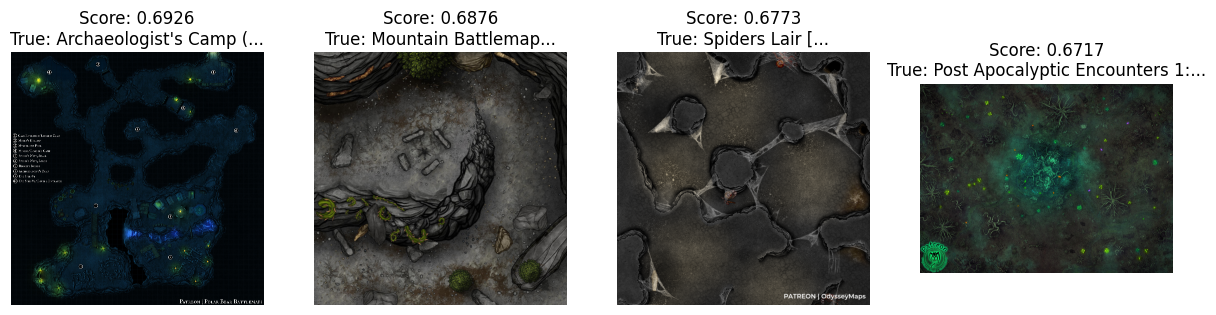

In [ ]:
text_prompt = "Dark cave with threasure"
draw_search_images(text_prompt, k=4)


Wyniki dla zapytania: 'Big castle'


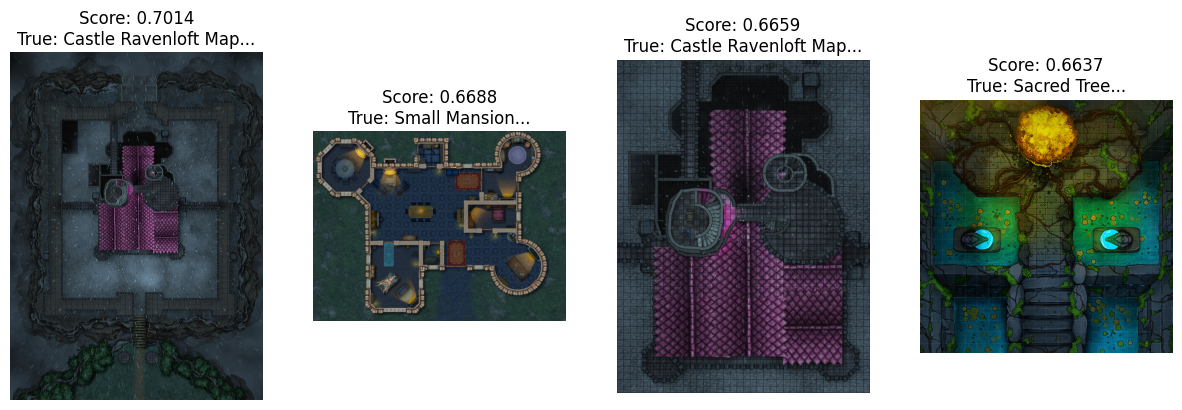

In [ ]:
text_prompt = "Big castle"
draw_search_images(text_prompt, k=4)


Wyniki dla zapytania: 'Forest, path, stones, river'


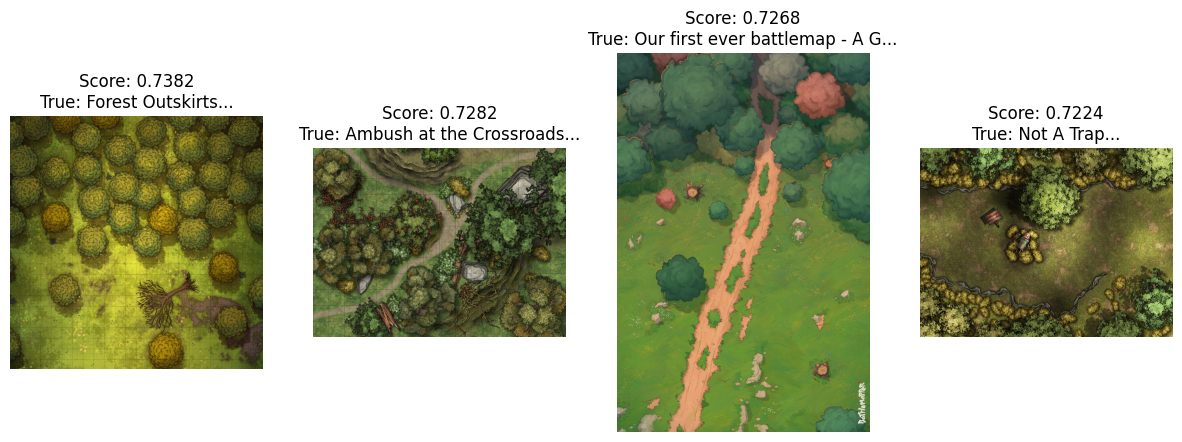

In [ ]:
text_prompt = "Forest, path, stones, river"
draw_search_images(text_prompt, k=4)

In [ ]:
torch.save(clip_model.state_dict(), 'clip.pt')

In [ ]:
clip_model = CLIPModel()
clip_model.load_state_dict(torch.load('clip.pt', weights_only=True))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clip_model.to(device)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

CLIPModel(
  (text_encoder): TextEncoder(
    (backbone): DistilBertModel(
      (embeddings): Embeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (transformer): Transformer(
        (layer): ModuleList(
          (0-5): 6 x TransformerBlock(
            (attention): DistilBertSdpaAttention(
              (dropout): Dropout(p=0.1, inplace=False)
              (q_lin): Linear(in_features=768, out_features=768, bias=True)
              (k_lin): Linear(in_features=768, out_features=768, bias=True)
              (v_lin): Linear(in_features=768, out_features=768, bias=True)
              (out_lin): Linear(in_features=768, out_features=768, bias=True)
            )
            (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (ffn): FFN(
            

In [ ]:
test_loader = dataloader['test']

In [ ]:
loss_metric = torchmetrics.aggregation.MeanMetric().to(device)
img_acc_metric = torchmetrics.aggregation.MeanMetric().to(device)
cap_acc_metric = torchmetrics.aggregation.MeanMetric().to(device)

clip_model.eval()
with torch.no_grad():
  for batch in tqdm(test_loader):
    batch['image'] = batch['image'].to(device)
    batch['input_ids'] = batch['input_ids'].to(device)
    batch['attention_mask'] = batch['attention_mask'].to(device)
    text_embeddings, image_embeddings = clip_model(batch)
    loss, img_acc, cap_acc = CLIP_loss(text_embeddings, image_embeddings)

    loss_metric.update(loss.item())
    img_acc_metric.update(img_acc)
    cap_acc_metric.update(cap_acc)

print(f"Loss: {loss_metric.compute():.3f}  img2text acc: {img_acc_metric.compute():.3f}  txt2img acc: {cap_acc_metric.compute():.3f}")

100%|██████████| 8/8 [02:32<00:00, 19.12s/it]

Loss: 2.687  img2text acc: 0.258  txt2img acc: 0.258


In [ ]:
!pip install -q torchinfo

In [ ]:
import torchinfo
import torch

dummy_input = {
    'image': torch.randn(1, 3, Config.image_size, Config.image_size).to(device), # Batch size 1, 3 channels, HxW
    'input_ids': torch.randint(0, tokenizer.vocab_size, (1, Config.max_tokens)).to(device), # Batch size 1, max_tokens
    'attention_mask': torch.ones(1, Config.max_tokens).to(device) # Batch size 1, max_tokens
}

torchinfo.summary(clip_model, input_data=(dummy_input,), verbose=0)

Layer (type:depth-idx)                                       Output Shape              Param #
CLIPModel                                                    [1, 256]                  --
├─TextEncoder: 1-1                                           [1, 256]                  --
│    └─DistilBertModel: 2-1                                  [1, 128, 768]             --
│    │    └─Embeddings: 3-1                                  [1, 128, 768]             23,835,648
│    │    └─Transformer: 3-2                                 [1, 128, 768]             42,527,232
│    └─ProjectionHead: 2-2                                   [1, 256]                  --
│    │    └─Linear: 3-3                                      [1, 256]                  196,608
├─ImageEncoder: 1-2                                          [1, 256]                  --
│    └─ResNet: 2-3                                           [1, 2048]                 --
│    │    └─Conv2d: 3-4                                      [1, 64, 112, 